### PySpark Otomoto Demo

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023


In [9]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [10]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [32]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [33]:
df.show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [34]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [35]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [36]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [37]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka
+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [38]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [40]:
df.createOrReplaceTempView("cars")

In [41]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [42]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [43]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [44]:
# zależność ceny od przebiegu
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


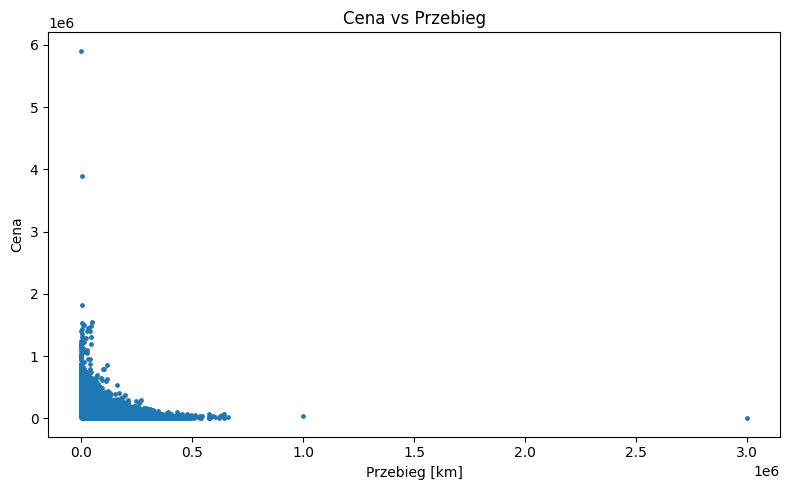

In [45]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [1]:
# Tutaj wpisz swój kod zliczający, czytający plik itp.
# Podpowiedź krok 1:
# df_crimes = spark.read.option("header", True).csv("chicago_crimes_sample.csv")
# df_crimes.show(5)


1. Wczytanie i Czyszczenie Danych

In [11]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
import pyspark.sql.functions as F
from pyspark.sql.functions import when, col

spark = SparkSession.builder \
    .appName("Chicago Crimes Analysis") \
    .getOrCreate()

# Wczytanie danych
df_crimes = spark.read.option("header", True).csv("chicago_crimes_sample.csv")

print("Oryginalna liczba wierszy:", df_crimes.count())
df_crimes.printSchema()

Oryginalna liczba wierszy: 149848
root
 |-- id: string (nullable = true)
 |-- case_number: string (nullable = true)
 |-- date: string (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: string (nullable = true)
 |-- domestic: string (nullable = true)
 |-- beat: string (nullable = true)
 |-- district: string (nullable = true)
 |-- ward: string (nullable = true)
 |-- community_area: string (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: string (nullable = true)
 |-- y_coordinate: string (nullable = true)
 |-- year: string (nullable = true)
 |-- updated_on: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- location: string (nullable = true)



In [12]:
# Czyszczenie
df_clean = df_crimes \
    .dropDuplicates() \
    .na.drop(subset=["date", "primary_type", "location_description"]) \
    .filter(F.col("date").isNotNull())

# Naprawa daty - obsługa wielu formatów
fmt1 = "MM/dd/yyyy hh:mm:ss a"      # stary format
fmt2 = "yyyy-MM-dd'T'HH:mm:ss.SSS"  # nowy format

df_clean = df_clean \
    .withColumn("timestamp",
        when(col("date").rlike(r"^\d{1,2}/\d{1,2}/\d{4}"),
             F.to_timestamp(col("date"), fmt1))
        .otherwise(
             F.to_timestamp(col("date"), fmt2)
        )
    ) \
    .withColumn("year", F.year(col("timestamp"))) \
    .withColumn("hour", F.hour(col("timestamp"))) \
    .withColumn("date_clean", col("timestamp"))

print("Po czyszczeniu:", df_clean.count())
df_clean.select("date", "year", "hour", "date_clean").show(10, truncate=False)

Po czyszczeniu: 49803
+-----------------------+----+----+-------------------+
|date                   |year|hour|date_clean         |
+-----------------------+----+----+-------------------+
|2026-05-06T15:00:00.000|2026|15  |2026-05-06 15:00:00|
|2026-05-06T15:00:00.000|2026|15  |2026-05-06 15:00:00|
|2026-05-05T11:55:00.000|2026|11  |2026-05-05 11:55:00|
|2026-05-05T07:00:00.000|2026|7   |2026-05-05 07:00:00|
|2026-05-05T06:00:00.000|2026|6   |2026-05-05 06:00:00|
|2026-05-05T00:30:00.000|2026|0   |2026-05-05 00:30:00|
|2026-05-04T23:00:00.000|2026|23  |2026-05-04 23:00:00|
|2026-05-04T13:14:00.000|2026|13  |2026-05-04 13:14:00|
|2026-05-04T01:06:00.000|2026|1   |2026-05-04 01:06:00|
|2026-05-03T19:00:00.000|2026|19  |2026-05-03 19:00:00|
+-----------------------+----+----+-------------------+
only showing top 10 rows


2. UDF i Pora Dnia

In [13]:
# UDF do klasyfikacji pory dnia
def get_time_of_day(hour):
    if hour is None:
        return "Unknown"
    if 0 <= hour < 6:
        return "Noc"
    elif 6 <= hour < 12:
        return "Poranek"
    elif 12 <= hour < 18:
        return "Dzień"
    else:
        return "Wieczór"

time_udf = F.udf(get_time_of_day, StringType())

df_with_time = df_clean.withColumn("time_of_day", time_udf(F.col("hour")))

df_with_time.groupBy("time_of_day").count().orderBy("count", ascending=False).show()

+-----------+-----+
|time_of_day|count|
+-----------+-----+
|      Dzień|16037|
|    Wieczór|14054|
|    Poranek|10654|
|        Noc| 9058|
+-----------+-----+



3. Optymalizacja i Partycjonowanie

In [14]:
# Cache po czyszczeniu i transformacjach
df_with_time = df_with_time.cache()

# Analiza najczęstszych przestępstw
crime_stats = df_with_time.groupBy("primary_type") \
    .agg(F.count("*").alias("count"),
         F.round(F.avg(F.col("hour")), 1).alias("avg_hour")) \
    .orderBy(F.desc("count"))

crime_stats.show(10)

# Broadcast join z małą tabelą (np. słownik lokalizacji)
location_dict = spark.createDataFrame([
    ("STREET", "Ulica"),
    ("RESIDENCE", "Mieszkanie"),
    ("APARTMENT", "Apartament")
], ["location_description", "location_pl"])

df_joined = df_with_time.join(F.broadcast(location_dict),
                              on="location_description",
                              how="left")

# Zapis do Parquet z partycjonowaniem po roku
df_joined.write.mode("overwrite").partitionBy("year").parquet("/tmp/chicago_crimes_clean")
print("Zapisano partycjonowany Parquet!")

+-------------------+-----+--------+
|       primary_type|count|avg_hour|
+-------------------+-----+--------+
|              THEFT|10920|    12.9|
|            BATTERY| 9253|    12.8|
|    CRIMINAL DAMAGE| 5497|    11.8|
|            ASSAULT| 4564|    13.1|
|MOTOR VEHICLE THEFT| 3886|    12.9|
|      OTHER OFFENSE| 3459|    12.9|
|           BURGLARY| 3163|    11.5|
| DECEPTIVE PRACTICE| 2486|    11.4|
|          NARCOTICS| 1455|    14.3|
|  CRIMINAL TRESPASS| 1193|    12.6|
+-------------------+-----+--------+
only showing top 10 rows
Zapisano partycjonowany Parquet!


4. Analiza i Plany Zapytań

In [15]:
# Ciężka agregacja - przykładowe zapytanie
heavy_query = df_with_time \
    .filter(F.col("year") >= 2024) \
    .groupBy("primary_type", "time_of_day", "location_description") \
    .agg(F.count("*").alias("incidents"),
         F.sum(F.when(F.col("arrest") == "true", 1).otherwise(0)).alias("arrests")) \
    .orderBy(F.desc("incidents"))

heavy_query.explain(mode="formatted")  # Pokazuje plan zapytania
heavy_query.show(15)

== Physical Plan ==
AdaptiveSparkPlan (28)
+- Sort (27)
   +- Exchange (26)
      +- HashAggregate (25)
         +- Exchange (24)
            +- HashAggregate (23)
               +- Project (22)
                  +- Filter (21)
                     +- InMemoryTableScan (1)
                           +- InMemoryRelation (2)
                                 +- AdaptiveSparkPlan (20)
                                    +- == Final Plan ==
                                       ResultQueryStage (12)
                                       +- * Project (11)
                                          +- BatchEvalPython (10)
                                             +- * Project (9)
                                                +- * HashAggregate (8)
                                                   +- ShuffleQueryStage (7), Statistics(sizeInBytes=21.3 MiB, rowCount=4.98E+4)
                                                      +- Exchange (6)
                                             

5. Uczenie Maszynowe (MLlib)

In [16]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

# Przygotowanie cech
indexer = StringIndexer(inputCol="time_of_day", outputCol="time_idx")
assembler = VectorAssembler(inputCols=["hour", "time_idx"], outputCol="features")

rf = RandomForestClassifier(labelCol="primary_type_idx", featuresCol="features", numTrees=20)

type_indexer = StringIndexer(inputCol="primary_type", outputCol="primary_type_idx")

pipeline = Pipeline(stages=[type_indexer, indexer, assembler, rf])

# Podział na train/test
train, test = df_with_time.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train)
predictions = model.transform(test)

predictions.groupBy("primary_type", "prediction").count().show()

+-------------------+----------+-----+
|       primary_type|prediction|count|
+-------------------+----------+-----+
|            BATTERY|       1.0|  702|
| DECEPTIVE PRACTICE|       0.0|  386|
|           BURGLARY|       1.0|  213|
|MOTOR VEHICLE THEFT|       1.0|  355|
|            BATTERY|       0.0| 1104|
|    CRIMINAL DAMAGE|       2.0|   78|
|    CRIMINAL DAMAGE|       1.0|  443|
|            BATTERY|       2.0|   75|
|           BURGLARY|       2.0|   51|
|            ASSAULT|       2.0|   23|
|MOTOR VEHICLE THEFT|       0.0|  397|
|              THEFT|       0.0| 1673|
|            ASSAULT|       1.0|  238|
|              THEFT|       1.0|  516|
|           BURGLARY|       0.0|  326|
|      OTHER OFFENSE|       1.0|  182|
|    CRIMINAL DAMAGE|       0.0|  592|
|          NARCOTICS|       0.0|  207|
|  WEAPONS VIOLATION|       0.0|  115|
|      OTHER OFFENSE|       0.0|  487|
+-------------------+----------+-----+
only showing top 20 rows
